# Mathematische Grundlagen für Differentialgleichungen

Begleitendes Notebook zu *Angew.Mathe.0MathematischeGrundlagen*: partielle Integration, Integration durch Substitution, Partialbruchzerlegung, Taylorpolynome, komplexe Zahlen, Eigenwerte und lineare Dynamik.

**Voraussetzungen:** `numpy`, `sympy`, `matplotlib`  
**Arbeitsweise:** Zellen der Reihe nach ausführen und die Kontrollausgaben prüfen.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/karkessler/dhbw-mathe3/blob/main/notebooks/differentialgleichungen/00_mathematische_grundlagen.ipynb)

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

## 1. Partielle Integration

Wir berechnen $\int x^2e^x\,dx$ symbolisch und prüfen das Ergebnis durch Ableiten.

In [2]:
x = sp.symbols('x', real=True)
f = x**2 * sp.exp(x)
F = sp.integrate(f, x)
kontrolle = sp.simplify(sp.diff(F, x) - f)
print('Stammfunktion:')
display(F)
print('Ableitung minus Integrand =', kontrolle)
assert kontrolle == 0

Stammfunktion:


Ableitung minus Integrand = 0


Die tabellarische partielle Integration liefert $e^x(x^2-2x+2)+C$. SymPy schreibt denselben Ausdruck gegebenenfalls faktorisiert.

## 2. Integration durch Substitution

Bei der Substitution wird eine innere Funktion als neue Variable gewählt. Für $\int 2x\cos(x^2)\,dx$ setzen wir $u=x^2$; dann ist $du=2x\,dx$ und das Integral wird zu $\int\cos(u)\,du=\sin(u)+C$. Nach dem Rückeinsetzen ergibt sich $\sin(x^2)+C$.

Die beiden Flächenplots zeigen dieselbe Fläche in zwei Koordinaten: links den ursprünglichen Integranden als Funktion von $x$, rechts den transformierten Integranden $\cos(u)$ als Funktion der neuen Variablen $u$. Für die Grenzen $0\leq x\leq\sqrt{\pi/2}$ beziehungsweise $0\leq u\leq\pi/2$ stimmen die Flächeninhalte überein.

Stammfunktion:


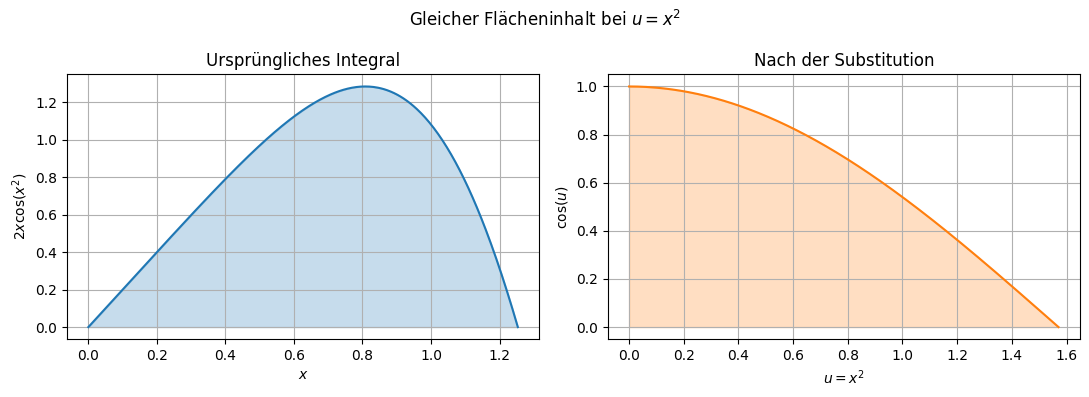

Fläche in x-Koordinaten: 0.999993189320339
Fläche in u-Koordinaten: 0.9999987084452265


In [3]:
u = sp.symbols('u', real=True)
integrand_sub = 2 * x * sp.cos(x**2)
F_sub = sp.integrate(integrand_sub, x)
print('Stammfunktion:')
display(F_sub)
assert sp.simplify(sp.diff(F_sub, x) - integrand_sub) == 0

upper_x = np.sqrt(np.pi / 2)
x_values = np.linspace(0, upper_x, 400)
u_values = np.linspace(0, np.pi / 2, 400)
values_x = 2 * x_values * np.cos(x_values**2)
values_u = np.cos(u_values)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_values, values_x, color='#1f77b4')
axes[0].fill_between(x_values, values_x, alpha=0.25, color='#1f77b4')
axes[0].set(xlabel='$x$', ylabel='$2x\\cos(x^2)$', title='Ursprüngliches Integral')
axes[1].plot(u_values, values_u, color='#ff7f0e')
axes[1].fill_between(u_values, values_u, alpha=0.25, color='#ff7f0e')
axes[1].set(xlabel='$u=x^2$', ylabel='$\\cos(u)$', title='Nach der Substitution')
fig.suptitle('Gleicher Flächeninhalt bei $u=x^2$')
plt.tight_layout()
plt.show()
print('Fläche in x-Koordinaten:', np.trapz(values_x, x_values))
print('Fläche in u-Koordinaten:', np.trapz(values_u, u_values))

## 3. Partialbruchzerlegung

Ein gebrochenrationaler Integrand lässt sich oft in einfachere Brüche zerlegen. Für
$$\frac{2x+3}{(x+1)(x+2)}=\frac{1}{x+1}+\frac{1}{x+2}$$
können die beiden Summanden einzeln integriert werden. Auf einem Intervall ohne Polstellen, zum Beispiel für $x>-1$, ist daher eine Stammfunktion $\ln(x+1)+\ln(x+2)+C$.

Im Plot wird sichtbar, dass die Summe der beiden einfachen Brüche wieder den ursprünglichen Integranden ergibt. Die gestrichelten Geraden bei $x=-2$ und $x=-1$ markieren die Polstellen; dort ist die Funktion nicht definiert und Integrationsintervalle dürfen diese Stellen nicht überschreiten.

Partialbruchzerlegung:


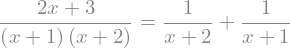

Stammfunktion auf x > -1:


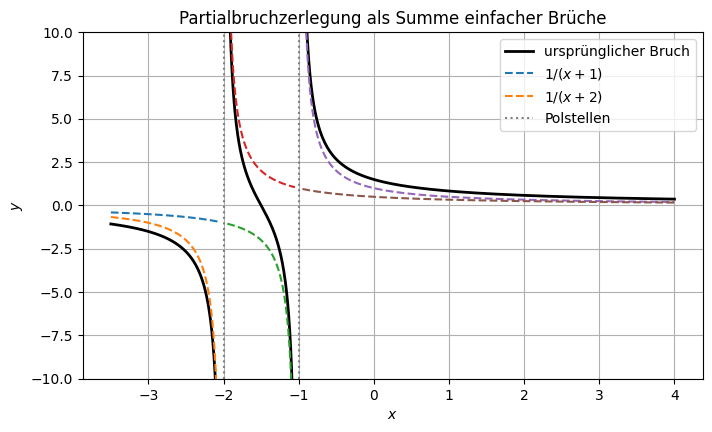

In [4]:
rational = (2 * x + 3) / ((x + 1) * (x + 2))
partial = sp.apart(rational, x)
F_rational = sp.integrate(partial, x)
print('Partialbruchzerlegung:')
display(sp.Eq(rational, partial, evaluate=False))
print('Stammfunktion auf x > -1:')
display(F_rational)
assert sp.simplify(rational - partial) == 0
assert sp.simplify(sp.diff(F_rational, x) - rational) == 0

rational_fn = sp.lambdify(x, rational, 'numpy')
part_1_fn = sp.lambdify(x, 1 / (x + 1), 'numpy')
part_2_fn = sp.lambdify(x, 1 / (x + 2), 'numpy')
intervals = [(-3.5, -2.05), (-1.95, -1.05), (-0.95, 4)]
for index, (start, stop) in enumerate(intervals):
    values = np.linspace(start, stop, 300)
    plt.plot(values, rational_fn(values), color='black', linewidth=2,
             label='ursprünglicher Bruch' if index == 0 else None)
    plt.plot(values, part_1_fn(values), '--', label='$1/(x+1)$' if index == 0 else None)
    plt.plot(values, part_2_fn(values), '--', label='$1/(x+2)$' if index == 0 else None)
plt.axvline(-2, color='gray', linestyle=':', label='Polstellen')
plt.axvline(-1, color='gray', linestyle=':')
plt.ylim(-10, 10)
plt.xlabel('$x$'); plt.ylabel('$y$')
plt.title('Partialbruchzerlegung als Summe einfacher Brüche')
plt.legend()
plt.show()

## 4. Taylorpolynome und Näherungsfehler

Für $e^x$ vergleichen wir Taylorpolynome verschiedener Ordnung auf $[-1,1]$.

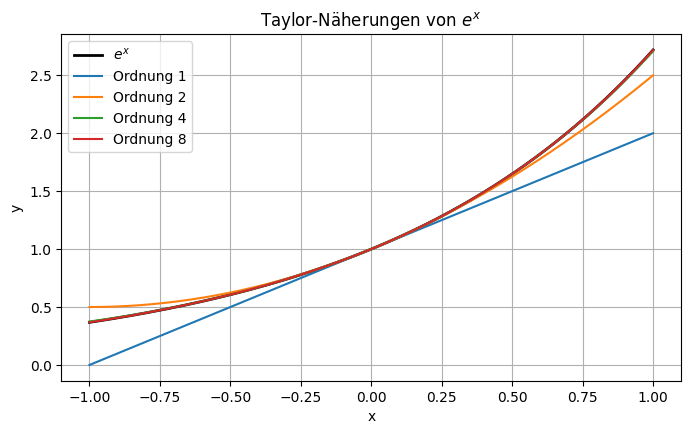

n=1: Näherung=1.100000000000, Fehler=5.171e-03
n=2: Näherung=1.105000000000, Fehler=1.709e-04
n=4: Näherung=1.105170833333, Fehler=8.474e-08
n=8: Näherung=1.105170918076, Fehler=3.109e-15


In [5]:
def taylor_exp(values, order):
    return sum(values**k / sp.factorial(k) for k in range(order + 1))

grid = np.linspace(-1, 1, 400)
plt.plot(grid, np.exp(grid), color='black', linewidth=2, label='$e^x$')
for n in (1, 2, 4, 8):
    approx = np.array(taylor_exp(grid, n), dtype=float)
    plt.plot(grid, approx, label=f'Ordnung {n}')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('Taylor-Näherungen von $e^x$');
plt.show()

for n in (1, 2, 4, 8):
    value = float(taylor_exp(0.1, n))
    print(f'n={n}: Näherung={value:.12f}, Fehler={abs(np.exp(0.1)-value):.3e}')

## 5. Komplexe Zahlen und die Euler-Formel

Eine komplexe Zahl $z=a+bi$ lässt sich als Punkt $(a,b)$ in der komplexen Ebene auffassen: $a=\operatorname{Re}(z)$ ist der Realteil und $b=\operatorname{Im}(z)$ der Imaginärteil. Besonders anschaulich ist die Exponentialfunktion auf der imaginären Achse. Die Euler-Formel
$$e^{i\theta}=\cos(\theta)+i\sin(\theta)$$
besagt, dass $e^{i\theta}$ beim Verändern von $\theta$ den Einheitskreis durchläuft. Real- und Imaginärteil sind also genau Kosinus und Sinus.

Für Differentialgleichungen ist die allgemeinere Form $e^{(\alpha+i\beta)t}=e^{\alpha t}(\cos(\beta t)+i\sin(\beta t))$ wichtig. Der Faktor $e^{\alpha t}$ bestimmt die Größe: Bei $\alpha<0$ entsteht eine Spirale zum Ursprung, bei $\alpha>0$ eine Spirale nach außen. Der Realteil $e^{\alpha t}\cos(\beta t)$ ist eine gedämpfte beziehungsweise anwachsende Schwingung; $\beta$ bestimmt ihre Kreisfrequenz.

Euler-Formel:


<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:26: SyntaxWarning: invalid escape sequence '\o'
C:\Users\kke\AppData\Local\Temp\ipykernel_32688\4053261339.py:26: SyntaxWarning: invalid escape sequence '\o'
  label='$\operatorname{Re}(e^{(-0.12+i)t})$')


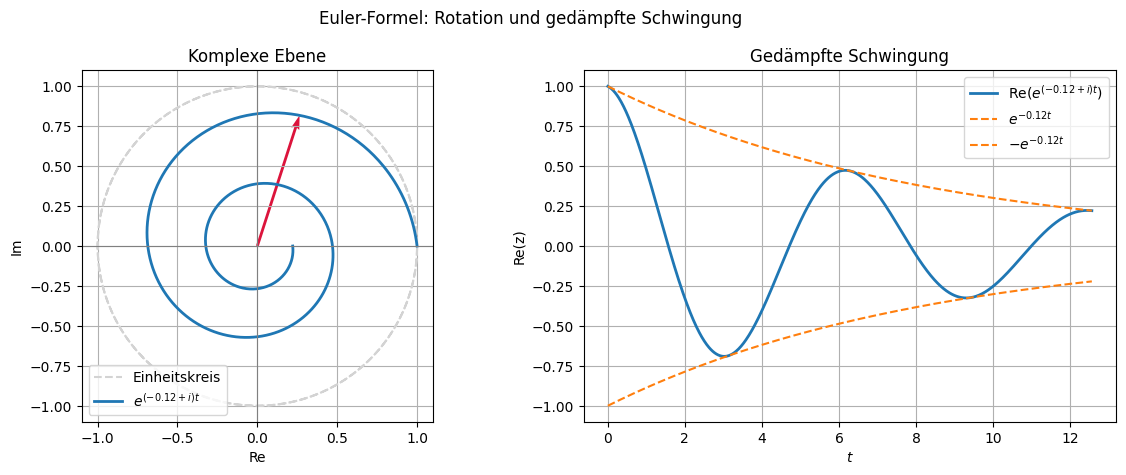

In [6]:
theta = sp.symbols('theta', real=True)
euler_difference = sp.simplify(
    sp.expand_complex(sp.exp(sp.I * theta)) - (sp.cos(theta) + sp.I * sp.sin(theta))
)
print('Euler-Formel:')
display(sp.Eq(sp.exp(sp.I * theta), sp.cos(theta) + sp.I * sp.sin(theta), evaluate=False))
assert euler_difference == 0

alpha, beta = -0.12, 1.0
t = np.linspace(0, 4 * np.pi, 800)
z = np.exp((alpha + 1j * beta) * t)
envelope = np.exp(alpha * t)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(np.cos(t), np.sin(t), '--', color='lightgray', label='Einheitskreis')
axes[0].plot(z.real, z.imag, color='#1f77b4', linewidth=2,
             label='$e^{(-0.12+i)t}$')
point = 80
axes[0].quiver(0, 0, z[point].real, z[point].imag, angles='xy', scale_units='xy',
               scale=1, color='crimson', width=0.008)
axes[0].axhline(0, color='gray', linewidth=0.8); axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set(xlabel='Re', ylabel='Im', title='Komplexe Ebene')
axes[0].set_aspect('equal'); axes[0].legend()

axes[1].plot(t, z.real, color='#1f77b4', linewidth=2,
             label='$\operatorname{Re}(e^{(-0.12+i)t})$')
axes[1].plot(t, envelope, '--', color='#ff7f0e', label='$e^{-0.12t}$')
axes[1].plot(t, -envelope, '--', color='#ff7f0e', label='$-e^{-0.12t}$')
axes[1].set(xlabel='$t$', ylabel='Re(z)', title='Gedämpfte Schwingung')
axes[1].legend()
fig.suptitle('Euler-Formel: Rotation und gedämpfte Schwingung')
plt.tight_layout()
plt.show()

## 6. Eigenwerte, Eigenvektoren und Diagonalisierung

Für die Matrix $A=\begin{pmatrix}4&1\\2&3\end{pmatrix}$ bestimmt das Notebook zunächst die Eigenwerte und zugehörigen Eigenvektoren. Die Eigenwerte $\lambda_1=2$ und $\lambda_2=5$ beschreiben die Streckung in den jeweiligen Eigenrichtungen. Die zugehörigen Eigenvektoren werden als Spalten zur Matrix $P$ zusammengefasst; die Eigenwerte stehen auf der Diagonalen von $D$.

Damit lässt sich $A$ als $A=PDP^{-1}$ schreiben. Diese Diagonalisierung bedeutet einen Koordinatenwechsel: In den durch die Eigenvektoren gegebenen Koordinaten wirkt $A$ besonders einfach, weil jede Koordinate nur mit ihrem Eigenwert multipliziert wird. Die Codezelle gibt die Eigenwertdaten sowie $P$ und $D$ aus und prüft abschließend durch $A-PDP^{-1}=0$, dass die Zerlegung korrekt ist.

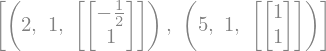

P =


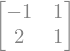

D =


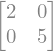

Kontrolle A - P D P^{-1} =


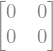

In [7]:
A = sp.Matrix([[4, 1], [2, 3]])
eigen = A.eigenvects()
display(eigen)
P, D = A.diagonalize()
print('P ='); display(P)
print('D ='); display(D)
print('Kontrolle A - P D P^{-1} =')
display(sp.simplify(A - P * D * P.inv()))
assert A == P * D * P.inv()

## 7. Eigenrichtungen in einem stabilen dynamischen System

Wir betrachten das lineare System $z'(t)=A_\mathrm{stabil}z(t)$ mit $A_\mathrm{stabil}=\begin{pmatrix}-1&1\\0&-2\end{pmatrix}$. Seine Eigenwerte sind $-1$ und $-2$. Beide haben einen negativen Realteil; deshalb ist der Nullpunkt asymptotisch stabil und jede Lösung nähert sich für $t\to\infty$ dem Ursprung.

Die Eigenvektoren geben dabei die Eigenrichtungen an: Startet eine Lösung auf einer solchen Geraden, bleibt sie auf ihr und klingt wie $e^{\lambda t}$ ab. Für die Anfangsbedingung $z(0)=(2,1)^T$ zerlegt die Codezelle den Anfangsvektor in diese Eigenrichtungen. Anschließend berechnet sie die Zeitentwicklung jeder Komponente mit $e^{\lambda t}$ und zeichnet $z_1(t)$ und $z_2(t)$. Da der Anteil zu $\lambda=-2$ schneller abklingt als der zu $\lambda=-1$, prägt langfristig die langsamere Eigenrichtung den Verlauf.

Eigenwerte: [-1. -2.]
Stabil, weil alle Realteile negativ: True


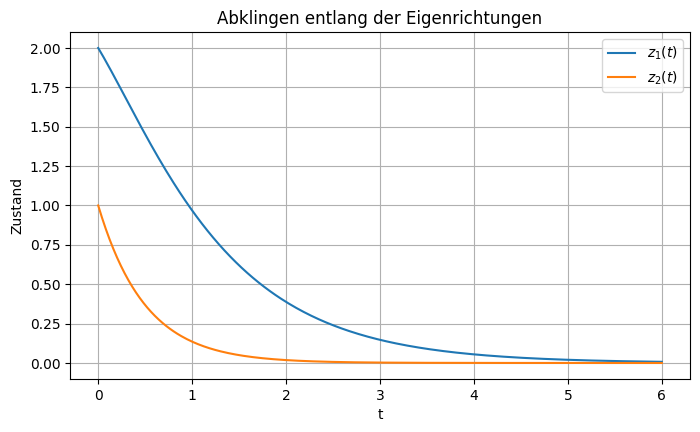

In [8]:
A_stabil = np.array([[-1.0, 1.0], [0.0, -2.0]])
vals, vecs = np.linalg.eig(A_stabil)
print('Eigenwerte:', vals)
print('Stabil, weil alle Realteile negativ:', np.all(np.real(vals) < 0))

t = np.linspace(0, 6, 300)
z0 = np.array([2.0, 1.0])
V = vecs
coeff = np.linalg.solve(V, z0)
traj = np.array([V @ (np.exp(vals * ti) * coeff) for ti in t]).real
plt.plot(t, traj[:, 0], label='$z_1(t)$')
plt.plot(t, traj[:, 1], label='$z_2(t)$')
plt.xlabel('t'); plt.ylabel('Zustand'); plt.legend();
plt.title('Abklingen entlang der Eigenrichtungen'); plt.show()